In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Libraries needed

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_file

Dataset paths

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder for this model
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["depth_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "depth_raw.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())
df["depth_exists"] = df["depth_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:  ", (~df["rgb_exists"]).sum())
print("Missing depth images:", (~df["depth_exists"]).sum())

# Keep only rows where both exist
df = df[df["rgb_exists"] & df["depth_exists"]].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print(df.head())

Missing RGB images:   0
Missing depth images: 0

Remaining samples after filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                            rgb_path  \
0  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  /content/drive/MyDrive/Speciale/dataset/nutrit...   
2  /content/drive/MyDrive/Speciale/dataset/nutrit...   
3  /content/drive/MyDrive/Speciale/dataset/nutrit...   
4  /content/drive/MyDrive/Speciale/dataset/nutrit...   

                                          depth_path  rgb_exists  depth_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...        True          True  
1  /content/drive/MyDrive/Spec

Creating Train / Validation / Test splits

In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Model parameters

In [ ]:
IMG_HEIGHT = 640
IMG_WIDTH = 480
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 300

Data loader

In [ ]:
def load_rgb_image(rgb_path):
    rgb = tf.io.read_file(rgb_path)
    rgb = tf.image.decode_png(rgb, channels=3)
    rgb = tf.image.resize(rgb, [IMG_HEIGHT, IMG_WIDTH])
    rgb = tf.cast(rgb, tf.float32)
    return rgb


def load_depth_image(depth_path):
    """
    Loads raw depth image as 1-channel.
    Assumes depth_raw.png is stored as uint16.
    Depth is normalized to [0,1] by dividing by 65535.
    """
    depth = tf.io.read_file(depth_path)

    depth = tf.image.decode_png(depth, channels=1, dtype=tf.uint16)

    # Resize depth map
    depth = tf.image.resize(depth, [IMG_HEIGHT, IMG_WIDTH], method="nearest")

    # Convert to float32
    depth = tf.cast(depth, tf.float32)

    # Normalize depth to [0,1]
    depth = depth / 65535.0

    return depth


def load_rgb_depth_and_label(rgb_path, depth_path, label):
    rgb = load_rgb_image(rgb_path)
    depth = load_depth_image(depth_path)
    label = tf.cast(label, tf.float32)

    return {
        "rgb_input": rgb,
        "depth_input": depth
    }, label

In [ ]:
def make_dataset(dataframe, batch_size=8, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    depth_paths = dataframe["depth_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, depth_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_depth_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Chekcs for correct creation of images

In [ ]:
for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:   ", batch_inputs["rgb_input"].shape)
    print("Depth batch shape: ", batch_inputs["depth_input"].shape)
    print("Labels batch shape:", batch_labels.shape)

RGB batch shape:    (32, 640, 480, 3)
Depth batch shape:  (32, 640, 480, 1)
Labels batch shape: (32,)


In [ ]:
from pathlib import Path
import os

def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)
df["depth_size"] = df["depth_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] == 0).sum())
print("Empty depth files:", (df["depth_size"] == 0).sum())

print("\nExample empty RGB files:")
print(df.loc[df["rgb_size"] == 0, ["dish_id", "rgb_path"]].head())

print("\nExample empty depth files:")
print(df.loc[df["depth_size"] == 0, ["dish_id", "depth_path"]].head())

Empty RGB files: 0
Empty depth files: 1

Example empty RGB files:
Empty DataFrame
Columns: [dish_id, rgb_path]
Index: []

Example empty depth files:
              dish_id                                         depth_path
2280  dish_1564159636  /content/drive/MyDrive/Speciale/dataset/nutrit...


In [ ]:
df["rgb_size"] = df["rgb_path"].apply(lambda p: Path(p).stat().st_size if Path(p).exists() else -1)
df["depth_size"] = df["depth_path"].apply(lambda p: Path(p).stat().st_size if Path(p).exists() else -1)

df = df[
    (df["rgb_exists"]) &
    (df["depth_exists"]) &
    (df["rgb_size"] > 0) &
    (df["depth_size"] > 0)
].copy()

print("Remaining samples after removing empty files:")
print(df["split"].value_counts())

Remaining samples after removing empty files:
split
train    2420
test      507
val       334
Name: count, dtype: int64


*Note that if any missing images are found go back and rerun the code block which creates the splits between the datasets.

Model architecture

In [ ]:
from tensorflow.keras.applications import EfficientNetV2S

# =========================================================
# RGB pretrained backbone
# =========================================================
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# First stage: freeze pretrained backbone
base_model.trainable = False

# =========================================================
# RGB input branch
# =========================================================
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

# EfficientNetV2 preprocessing
rgb_x = keras.applications.efficientnet_v2.preprocess_input(rgb_input)

# Forward pass through pretrained backbone
rgb_feat = base_model(rgb_x, training=False)   # keep spatial feature map

# =========================================================
# Depth input branch -> guidance mask
# =========================================================
depth_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name="depth_input")

# depth_input is already normalized to [0,1] in the loader
depth_x = layers.Conv2D(16, 3, padding="same", use_bias=False, name="depth_conv1")(depth_input)
depth_x = layers.BatchNormalization(name="depth_bn1")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu1")(depth_x)
depth_x = layers.MaxPooling2D(2, name="depth_pool1")(depth_x)

depth_x = layers.Conv2D(32, 3, padding="same", use_bias=False, name="depth_conv2")(depth_x)
depth_x = layers.BatchNormalization(name="depth_bn2")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu2")(depth_x)
depth_x = layers.MaxPooling2D(2, name="depth_pool2")(depth_x)

depth_x = layers.Conv2D(64, 3, padding="same", use_bias=False, name="depth_conv3")(depth_x)
depth_x = layers.BatchNormalization(name="depth_bn3")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu3")(depth_x)
depth_x = layers.MaxPooling2D(2, name="depth_pool3")(depth_x)

depth_x = layers.Conv2D(128, 3, padding="same", use_bias=False, name="depth_conv4")(depth_x)
depth_x = layers.BatchNormalization(name="depth_bn4")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu4")(depth_x)

# Convert depth features into a single spatial attention mask
depth_mask = layers.Conv2D(1, 1, padding="same", activation="sigmoid", name="depth_mask")(depth_x)

# =========================================================
# Resize mask to match RGB feature map size
# =========================================================
def resize_mask_to_rgb(inputs):
    mask, rgb = inputs
    target_size = tf.shape(rgb)[1:3]
    return tf.image.resize(mask, target_size, method="bilinear")

depth_mask_resized = layers.Lambda(
    resize_mask_to_rgb,
    name="resize_depth_mask"
)([depth_mask, rgb_feat])

# =========================================================
# Depth-guided RGB modulation
# Residual-style gating
# gated_rgb = rgb_feat * (1 + mask)
# =========================================================
one_plus_mask = layers.Lambda(lambda m: 1.0 + m, name="one_plus_mask")(depth_mask_resized)
gated_rgb_feat = layers.Multiply(name="depth_guided_rgb")([rgb_feat, one_plus_mask])

# =========================================================
# Regression head
# =========================================================
x = layers.GlobalAveragePooling2D(name="rgb_guided_gap")(gated_rgb_feat)

# Also include pooled summary of the mask itself
mask_summary = layers.GlobalAveragePooling2D(name="mask_gap")(depth_mask_resized)
x = layers.Concatenate(name="fusion_concat")([x, mask_summary])

x = layers.Dropout(0.3, name="dropout")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)

outputs = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(
    inputs=[rgb_input, depth_input],
    outputs=outputs,
    name="efficientnetv2s_rgb_depth_pretrained_carb_regression_model_5_5"
)

model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "efficientnetv2s_rgb_depth_pretrained_carb_regression_model_5_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ depth_input         │ (None, 640, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv1         │ (None, 640, 480,  │        144 │ depth_input[0][0] │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn1           │ (None, 640, 480,  │         64 │ depth_conv1[0][0] │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_relu1         │ (None, 640, 480,  │          0 │ depth_bn1[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_pool1         │ (None, 320, 240,  │          0 │ depth_relu1[0][0] │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv2         │ (None, 320, 240,  │      4,608 │ depth_pool1[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn2           │ (None, 320, 240,  │        128 │ depth_conv2[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_relu2         │ (None, 320, 240,  │          0 │ depth_bn2[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_pool2         │ (None, 160, 120,  │          0 │ depth_relu2[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv3         │ (None, 160, 120,  │     18,432 │ depth_pool2[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn3           │ (None, 160, 120,  │        256 │ depth_conv3[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_relu3         │ (None, 160, 120,  │          0 │ depth_bn3[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_pool3         │ (None, 80, 60,    │          0 │ depth_relu3[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv4         │ (None, 80, 60,    │     73,728 │ depth_pool3[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn4           │ (None, 80, 60,    │        512 │ depth_conv4[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_input           │ (None, 640, 480,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_relu4         │ (None, 80, 60,    │          0 │ depth_bn4[0][0] 

 Total params: 20,790,578 (79.31 MB)

 Trainable params: 458,738 (1.75 MB)

 Non-trainable params: 20,331,840 (77.56 MB)

Compile stage 1

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=150,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=125,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 802.7706 - mae: 13.0227 - mse: 802.7706
Epoch 1: val_loss improved from None to 144.08025, saving model to /content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained/best_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 480s 5s/step - loss: 475.3522 - mae: 11.0305 - mse: 475.3522 - val_loss: 144.0802 - val_mae: 8.4791 - val_mse: 144.0802 - learning_rate: 0.0010
Epoch 2/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 179.4370 - mae: 8.5867 - mse: 179.4370
Epoch 2: val_loss improved from 144.08025 to 134.15953, saving model to /content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained/best_mo

Plotting training and validation curves

In [ ]:
def plot_metrics(history, title="Training history"):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title(f"{title} - Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title(f"{title} - Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title(f"{title} - Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

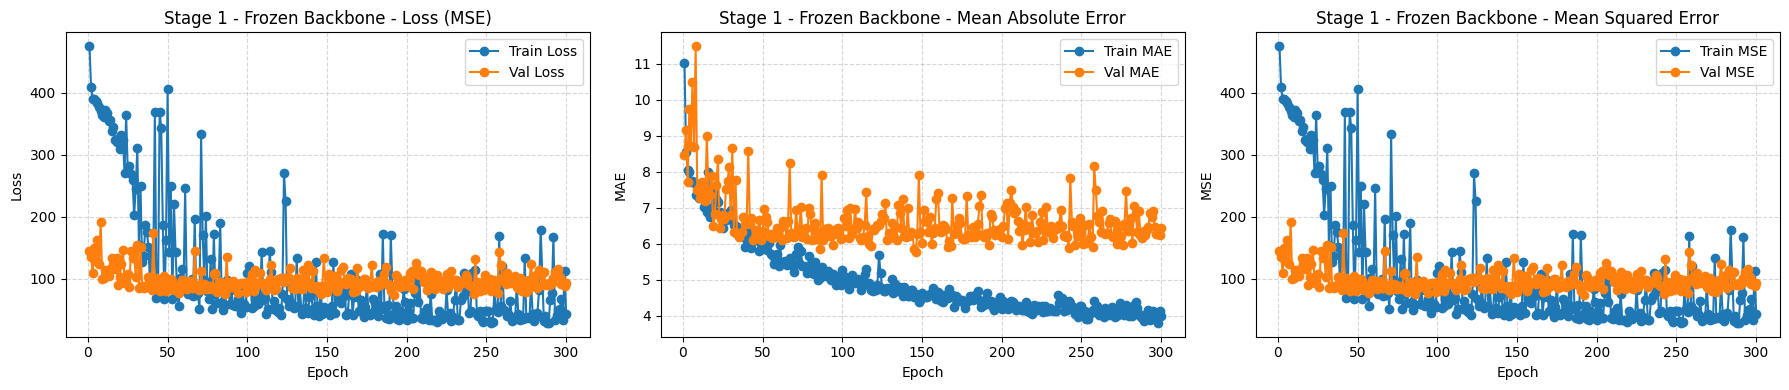

Best val_loss: 73.1449 at epoch 192
Val MAE at best epoch: 5.9507
Val MSE at best epoch: 73.1449


In [ ]:
plot_metrics(history, title="Stage 1 - Frozen Backbone")

Testing model

In [ ]:
loaded_model = tf.keras.models.load_model(str(OUTPUT_DIR / "best_model.keras"), compile=False)

In [ ]:
loaded_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

The previous code is only if it is needed to back and reload the model back in for testing.

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print("Current in-memory model test results:")
print(test_results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 780ms/step - loss: 72.4362 - mae: 5.3116 - mse: 72.4362
Current in-memory model test results:
{'loss': 72.43619537353516, 'mae': 5.311557769775391, 'mse': 72.43619537353516}


Stage 2 training (unfreezing more layers in the pretrained model)

In [ ]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 120

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Freeze BatchNormalization layers for stability
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Total layers in base_model:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)

trainable_count = np.sum([layer.trainable for layer in base_model.layers])
print("Trainable layers in base_model:", trainable_count)

Total layers in base_model: 513
Fine-tuning from layer index: 393
Trainable layers in base_model: 96


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage2_finetuned.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=300,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=275,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
EPOCHS_STAGE2 = 500

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_STAGE2,
    callbacks=stage2_callbacks
)

Epoch 1/500
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - loss: 61.9498 - mae: 4.5060 - mse: 61.9498
Epoch 1: val_loss improved from None to 77.56358, saving model to /content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained/best_model_stage2_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained/best_model_stage2_finetuned.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - loss: 108.7853 - mae: 4.5418 - mse: 108.7853 - val_loss: 77.5636 - val_mae: 5.9529 - val_mse: 77.5636 - learning_rate: 1.0000e-05
Epoch 2/500
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 71.4978 - mae: 4.4741 - mse: 71.4978
Epoch 2: val_loss did not improve from 77.56358
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - loss: 48.9133 - mae: 4.3117 - mse: 48.9133 - val_loss: 82.6654 - val_mae: 6.1032 - val_mse: 82.6654 - learning_rate: 1.0000e-05
Epoch 3/500
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 

Plotting stage 2

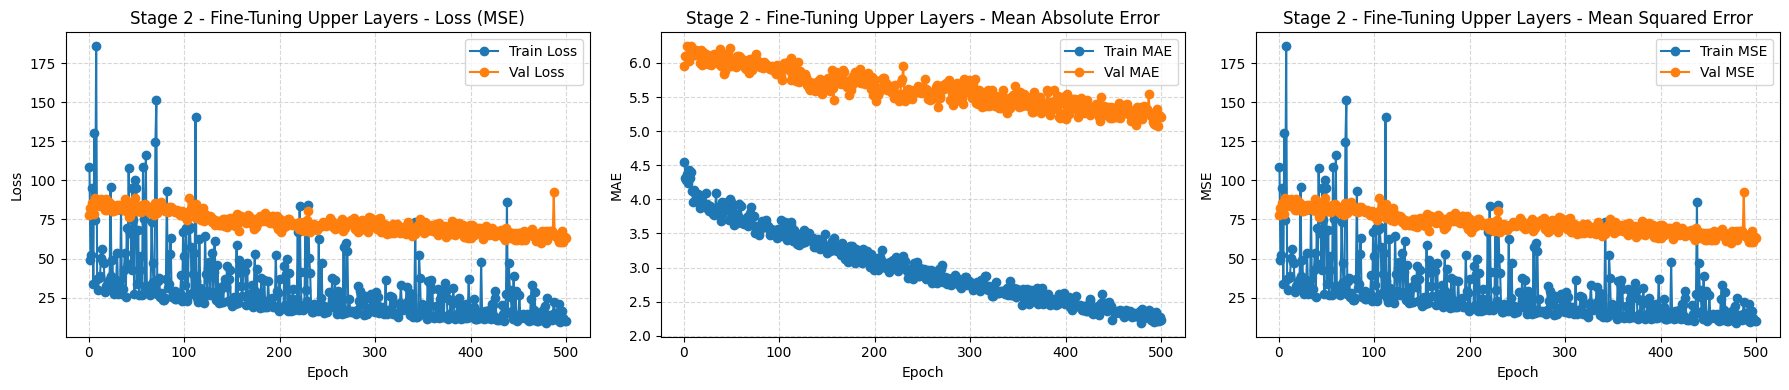

Best val_loss: 60.1055 at epoch 474
Val MAE at best epoch: 5.0915
Val MSE at best epoch: 60.1055


In [ ]:
plot_metrics(history_stage2, title="Stage 2 - Fine-Tuning Upper Layers")

Testing on test dataset

In [ ]:
best_stage2_model = tf.keras.models.load_model(
    str(OUTPUT_DIR / "best_model_stage2_finetuned.keras"),
    compile=False
)

TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': None}.

Exception encountered: <class 'keras.src.layers.core.lambda_layer.Lambda'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.layers', 'class_name': 'Lambda', 'config': {'name': 'resize_depth_mask', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_obj

In [ ]:
best_stage2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
best_stage2_results = best_stage2_model.evaluate(test_dataset, return_dict=True)
print("Loaded best stage 2 model test results:")
print(best_stage2_results)

NameError: name 'best_stage2_model' is not defined

Optional to save on huggingface.

In [ ]:
HF_REPO_ID = "AIJonas/nutrition5k-efficientnetv2s-rgb-plus-depth-carb-model-5-5"

create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)

model_card = f"""
---
license: mit
library_name: keras
tags:
- tensorflow
- keras
- computer-vision
- regression
- nutrition5k
- carbohydrate-estimation
- multimodal
- rgb-depth
- efficientnetv2
- pretrained
---

# EfficientNetV2S RGB + Depth Carbohydrate Regression (Model 5.5)

This model predicts dish-level carbohydrate content from overhead RGB images and overhead raw depth images from the Nutrition5K dataset.

## Architecture
- Dual-input multimodal regression model
- Pretrained EfficientNetV2S backbone for RGB input
- CNN-based depth guidance branch
- Depth-guided gating of RGB spatial features
- Global average pooling + fusion
- Fully connected regression head
- Final dense layer with linear activation for carbohydrate prediction

## Training procedure
- Stage 1: frozen EfficientNetV2S RGB backbone
- Stage 2: upper layers of EfficientNetV2S unfrozen for fine-tuning
- BatchNormalization layers kept frozen during fine-tuning for stability

## Input modalities
- `rgb_input`: overhead RGB image
- `depth_input`: overhead raw depth image

## Target
- `total_carb`
"""

with open(OUTPUT_DIR / "README.md", "w") as f:
    f.write(model_card)

upload_file(
    path_or_fileobj=str(OUTPUT_DIR / "best_model_stage2_finetuned.keras"),
    path_in_repo="best_model_stage2_finetuned.keras",
    repo_id=HF_REPO_ID,
    repo_type="model"
)

upload_file(
    path_or_fileobj=str(OUTPUT_DIR / "README.md"),
    path_in_repo="README.md",
    repo_id=HF_REPO_ID,
    repo_type="model"
)

print("Best stage 2 model and README uploaded to Hugging Face.")

Retesting model 5.5 to make sure the result is correct

In [ ]:
import zipfile
import shutil
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# ------------------------------------------------------------
# Checkpoint path
# ------------------------------------------------------------

stage2_checkpoint = OUTPUT_DIR / "best_model_stage2_finetuned.keras"

print("Stage 2 checkpoint:")
print(stage2_checkpoint)
print("Exists:", stage2_checkpoint.exists())

stat = stage2_checkpoint.stat()
print("Size:", stat.st_size)
print("Modified:", datetime.datetime.fromtimestamp(stat.st_mtime))

# ------------------------------------------------------------
# Custom Lambda function used in Model 5.5
# ------------------------------------------------------------

def resize_mask_to_rgb(inputs):
    depth_mask, rgb_features = inputs

    target_height = tf.shape(rgb_features)[1]
    target_width = tf.shape(rgb_features)[2]

    resized_mask = tf.image.resize(
        depth_mask,
        size=(target_height, target_width),
        method="bilinear"
    )

    return resized_mask


custom_objects = {
    "resize_mask_to_rgb": resize_mask_to_rgb
}


loaded_successfully = False

try:
    print("\nTrying to load full Stage 2 .keras model...")

    test_model = tf.keras.models.load_model(
        str(stage2_checkpoint),
        compile=False,
        safe_mode=False,
        custom_objects=custom_objects
    )

    loaded_successfully = True
    print("Full model loaded successfully.")

except Exception as e:
    print("\nFull model load failed:")
    print(repr(e))
    print("\nFalling back to: rebuilt architecture + extracted weights")

    # At this point, the original notebook should already have recreated `model`
    # from the architecture cell.
    test_model = model

    extract_dir = OUTPUT_DIR / "extracted_model_5_5_stage2_checkpoint"

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(stage2_checkpoint, "r") as z:
        z.extractall(extract_dir)

    print("\nExtracted files:")
    for p in extract_dir.rglob("*"):
        print(p.relative_to(extract_dir))

    possible_weight_files = list(extract_dir.rglob("*.h5"))

    if len(possible_weight_files) == 0:
        raise FileNotFoundError("No .h5 weights file found inside the .keras checkpoint.")

    weights_path = None

    for p in possible_weight_files:
        if "weights" in p.name.lower():
            weights_path = p
            break

    if weights_path is None:
        weights_path = possible_weight_files[0]

    print("\nUsing extracted weights:")
    print(weights_path)

    test_model.load_weights(str(weights_path))
    print("Weights loaded into rebuilt architecture successfully.")


print("\nModel inputs:")
for inp in test_model.inputs:
    print(inp.name, inp.shape)

# ------------------------------------------------------------
# Compile for evaluation
# ------------------------------------------------------------

test_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

print("\nEvaluating Stage 2 checkpoint on validation set...")
stage2_val_results = test_model.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=1
)

print("\nValidation results:")
print(stage2_val_results)

# ------------------------------------------------------------
# Final test-set evaluation
# ------------------------------------------------------------

print("\nEvaluating Stage 2 checkpoint on test set...")
stage2_test_results = test_model.evaluate(
    test_dataset,
    return_dict=True,
    verbose=1
)

print("\nTest results:")
print(stage2_test_results)

Stage 2 checkpoint:
/content/drive/MyDrive/Speciale/Models/Model_5_5_efficientnetv2s_rgb_plus_depth_pretrained/best_model_stage2_finetuned.keras
Exists: True
Size: 152139098
Modified: 2026-03-29 20:53:07

Trying to load full Stage 2 .keras model...
Full model loaded successfully.

Model inputs:
rgb_input (None, 640, 480, 3)
depth_input (None, 640, 480, 1)

Evaluating Stage 2 checkpoint on validation set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - loss: 60.0865 - mae: 5.0909 - mse: 60.0865 - rmse: 7.7515

Validation results:
{'loss': 60.08647537231445, 'mae': 5.090887546539307, 'mse': 60.08647537231445, 'rmse': 7.751546382904053}

Evaluating Stage 2 checkpoint on test set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 88s 5s/step - loss: 72.4380 - mae: 5.3106 - mse: 72.4380 - rmse: 8.5111

Test results:
{'loss': 72.43804168701172, 'mae': 5.310586452484131, 'mse': 72.43804168701172, 'rmse': 8.511054039001465}
